In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
import importlib.util
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium.wrappers import TimeLimit

# Load UnbalancedDisk.py directly — bypasses __init__.py which imports usb (hardware only)
_disk_path = os.path.join('..', 'gym_unbalanced_disk', 'envs', 'UnbalancedDisk.py')
_spec = importlib.util.spec_from_file_location('UnbalancedDisk', _disk_path)
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
UnbalancedDisk_sincos = _mod.UnbalancedDisk_sincos

# Patch reset() to accept modern gymnasium signature (seed, options)
class UnbalancedDiskSinCosFixed(UnbalancedDisk_sincos):
    def reset(self, seed=None, options=None):
        obs = super().reset()
        return (obs if isinstance(obs, tuple) else (obs, {}))

env = TimeLimit(UnbalancedDiskSinCosFixed(), max_episode_steps=500)

REWARD_WEIGHTS = {
    "swing_up":       1.0,
    "balance":        4.0,
    "low_speed":      2.0,
    "omega_penalty":  1.0,    # position-weighted (see below) — zero at bottom, full at top
    "action_penalty": 0.003,
}

def wrap_angle(theta):
    # maps any theta to [-pi, pi] with 0=bottom, +-pi=upright
    return (theta + np.pi) % (2 * np.pi) - np.pi

def _reward(self):
    theta  = self.th
    omega  = self.omega
    action = float(self.u) if self.u is not None else 0.0
    umax   = self.umax
    w      = REWARD_WEIGHTS

    theta_wrapped = wrap_angle(theta)
    upright_error = np.pi - abs(theta_wrapped)   # 0 at top, pi at bottom

    swing_up_reward = (1.0 - np.cos(theta_wrapped)) / 2.0
    balance_bonus   = np.exp(-(upright_error ** 2) / (2 * 0.30 ** 2))
    low_speed_bonus = (np.exp(-(omega ** 2) / (2 * 1.5 ** 2))
                       * np.exp(-(upright_error ** 2) / (2 * 0.45 ** 2)))

    # Position-weighted omega penalty:
    #   nearness_to_top = 0 at bottom  ->  zero penalty, momentum freely built
    #   nearness_to_top = 1 at upright ->  full penalty, stabilisation enforced
    #   avg over full spin = 0.5       ->  spinning above ~10 rad/s penalised
    nearness_to_top = (1.0 - np.cos(theta_wrapped)) / 2.0
    omega_penalty   = nearness_to_top * (omega / 10.0) ** 2

    action_penalty  = (action / umax) ** 2

    return (w["swing_up"]        * swing_up_reward
            + w["balance"]       * balance_bonus
            + w["low_speed"]     * low_speed_bonus
            - w["omega_penalty"] * omega_penalty
            - w["action_penalty"]* action_penalty)

env.env.reward_fun = _reward

print("Observation space:", env.observation_space)
print("Action space:     ", env.action_space)

Observation space: Box([ -1.  -1. -40.], [ 1.  1. 40.], (3,), float32)
Action space:      Box(-3.0, 3.0, (), float32)


## Actor Network (Gaussian policy)

In [2]:
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
        )
        self.mean_head    = nn.Linear(hidden, act_dim)
        self.log_std_head = nn.Linear(hidden, act_dim)

    def forward(self, x):
        h = self.net(x)
        mean    = self.mean_head(h)
        log_std = self.log_std_head(h).clamp(-2, 2)
        return mean, log_std

    def get_action(self, obs):
        mean, log_std = self(obs)
        std  = log_std.exp()
        dist = torch.distributions.Normal(mean, std)
        action   = dist.sample()
        log_prob = dist.log_prob(action).sum(-1)
        entropy  = dist.entropy().sum(-1)
        action   = action.clamp(-3., 3.)
        return action, log_prob, entropy

## Critic Network (state value estimator)

In [3]:
class Critic(nn.Module):
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

## A2C Training Loop

In [4]:
def train_a2c(env, actor, critic, n_episodes=2000, gamma=0.99,
              lr_actor=3e-4, lr_critic=1e-3, entropy_coef=0.01):

    opt_actor  = torch.optim.Adam(actor.parameters(),  lr=lr_actor)
    opt_critic = torch.optim.Adam(critic.parameters(), lr=lr_critic)

    returns_log = []

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done   = False
        log_probs, values, rewards, entropies = [], [], [], []

        while not done:
            obs_t              = torch.tensor(obs, dtype=torch.float32)
            action, log_prob, entropy = actor.get_action(obs_t)
            value              = critic(obs_t)

            obs_next, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            log_probs.append(log_prob)
            values.append(value)
            rewards.append(reward)
            entropies.append(entropy)

            obs = obs_next

        # Compute discounted returns
        G, returns = 0, []
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)

        returns    = torch.tensor(returns,  dtype=torch.float32)
        values     = torch.stack(values)
        log_probs  = torch.stack(log_probs)
        entropies  = torch.stack(entropies)

        advantages = returns - values.detach()
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        actor_loss  = -(log_probs * advantages).mean() - entropy_coef * entropies.mean()
        critic_loss = nn.functional.mse_loss(values, returns)

        opt_actor.zero_grad();  actor_loss.backward();  opt_actor.step()
        opt_critic.zero_grad(); critic_loss.backward(); opt_critic.step()

        returns_log.append(sum(rewards))
        if ep % 100 == 0:
            print(f"Ep {ep:4d} | Avg return (last 100): {np.mean(returns_log[-100:]):.2f}")

    return returns_log

## Run Training

Ep    0 | Avg return (last 100): 0.00
Ep  100 | Avg return (last 100): 19.54
Ep  200 | Avg return (last 100): 107.16
Ep  300 | Avg return (last 100): 110.05
Ep  400 | Avg return (last 100): 107.81
Ep  500 | Avg return (last 100): 105.49
Ep  600 | Avg return (last 100): 105.61
Ep  700 | Avg return (last 100): 105.80
Ep  800 | Avg return (last 100): 105.87
Ep  900 | Avg return (last 100): 105.98
Ep 1000 | Avg return (last 100): 105.41
Ep 1100 | Avg return (last 100): 104.43
Ep 1200 | Avg return (last 100): 105.03
Ep 1300 | Avg return (last 100): 105.28
Ep 1400 | Avg return (last 100): 107.77
Ep 1500 | Avg return (last 100): 109.47
Ep 1600 | Avg return (last 100): 113.50
Ep 1700 | Avg return (last 100): 116.60
Ep 1800 | Avg return (last 100): 114.24
Ep 1900 | Avg return (last 100): 118.63


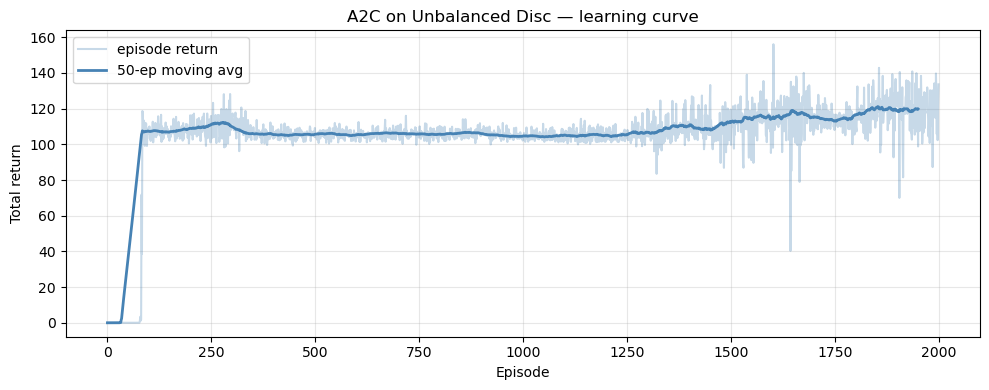

In [5]:
obs_dim = env.observation_space.shape[0]   # 3: [sin(θ), cos(θ), ω]
act_dim = 1                                # single continuous action

actor  = Actor(obs_dim, act_dim)
critic = Critic(obs_dim)

# Swing-up needs more episodes and stronger exploration
# - n_episodes=5000: swing-up is harder than stabilisation
# - entropy_coef=0.05: more exploration so policy tries large actions at the bottom
# - gamma=0.995: less discounting so late rewards (reaching top) credit early actions
returns_log = train_a2c(env, actor, critic, n_episodes=5000,
                        gamma=0.995, lr_actor=3e-4, lr_critic=1e-3,
                        entropy_coef=0.05)

# --- Sanity check: what does the actor output at the bottom? ---
import torch
actor.eval()
with torch.no_grad():
    bottom_obs = torch.tensor([0.0, 1.0, 0.0])  # sin(0), cos(0), omega=0
    mean, log_std = actor(bottom_obs)
    print(f'Action at bottom: mean={mean.item():.3f}, std={log_std.exp().item():.3f}')
    side_obs = torch.tensor([1.0, 0.0, 0.0])    # sin(pi/2), cos(pi/2), omega=0
    mean2, _ = actor(side_obs)
    print(f'Action at sideways: mean={mean2.item():.3f}')

# Plot learning curve
plt.figure(figsize=(10, 4))
plt.plot(returns_log, alpha=0.3, color='steelblue', label='episode return')
window = 100
plt.plot(np.convolve(returns_log, np.ones(window)/window, mode='valid'),
         color='steelblue', lw=2, label=f'{window}-ep moving avg')
plt.xlabel('Episode'); plt.ylabel('Total return')
plt.title('A2C on Unbalanced Disc — learning curve')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Policy Visualization — Mean Action ± 2σ vs Angle

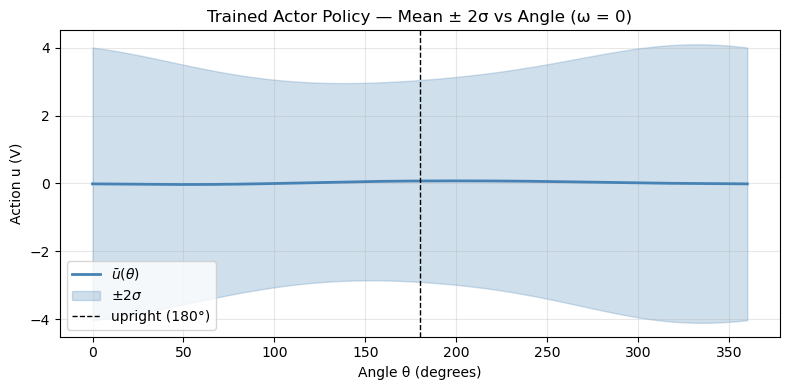

In [7]:
# Sweep θ from 0 to 2π with ω = 0, visualise actor mean ± 2σ
actor.eval()
critic.eval()

thetas = np.linspace(0, 2 * np.pi, 200)
mean_actions = []
std_actions  = []

with torch.no_grad():
    for th in thetas:
        obs_t = torch.tensor([np.sin(th), np.cos(th), 0.0], dtype=torch.float32)
        mean, log_std = actor(obs_t)
        mean_actions.append(mean.item())
        std_actions.append(log_std.exp().item())

mean_actions = np.array(mean_actions)
std_actions  = np.array(std_actions)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(thetas), mean_actions, color='steelblue', lw=2, label=r'$\bar{u}(\theta)$')
ax.fill_between(np.degrees(thetas),
                mean_actions - 2 * std_actions,
                mean_actions + 2 * std_actions,
                alpha=0.25, color='steelblue', label=r'$\pm 2\sigma$')
ax.axvline(180, color='k', ls='--', lw=1, label='upright (180°)')
ax.set_xlabel('Angle θ (degrees)')
ax.set_ylabel('Action u (V)')
ax.set_title('Trained Actor Policy — Mean ± 2σ vs Angle (ω = 0)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Value Function — V(s) vs Angle

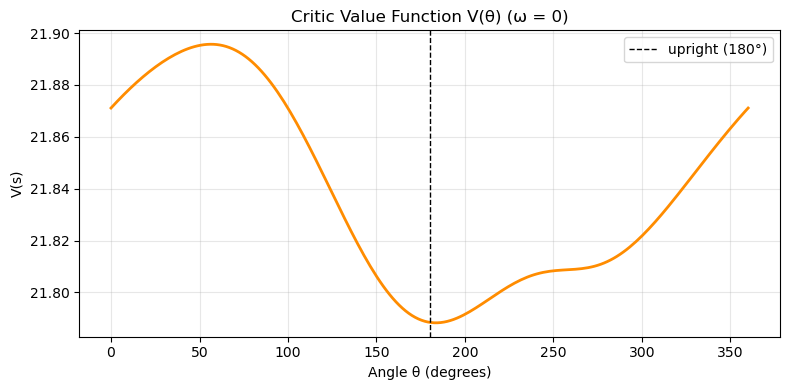

In [8]:
values = []
with torch.no_grad():
    for th in thetas:
        obs_t = torch.tensor([np.sin(th), np.cos(th), 0.0], dtype=torch.float32)
        values.append(critic(obs_t).item())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(thetas), values, color='darkorange', lw=2)
ax.axvline(180, color='k', ls='--', lw=1, label='upright (180°)')
ax.set_xlabel('Angle θ (degrees)')
ax.set_ylabel('V(s)')
ax.set_title('Critic Value Function V(θ) (ω = 0)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Simulation Rollout — Run Trained Policy in Simulator

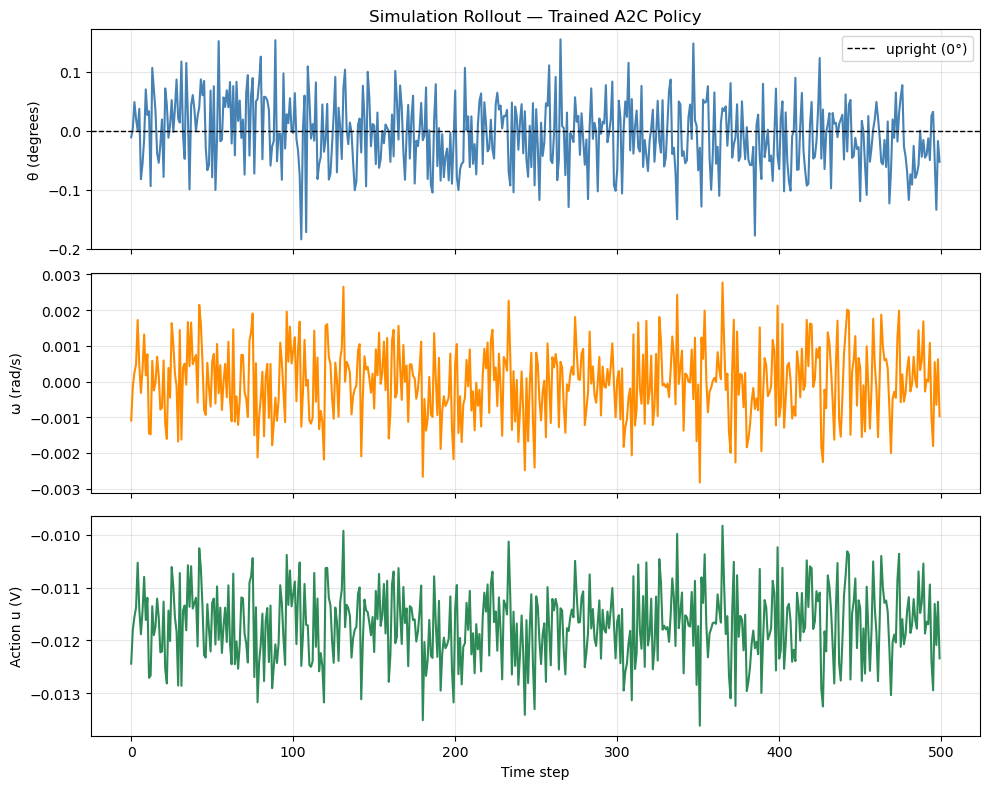

Episode length: 500 steps | Total reward: 0.00


In [9]:
def run_episode(actor, env, deterministic=True, max_steps=500):
    obs, _ = env.reset()  # starts at bottom (th~0)
    thetas_ep, omegas_ep, actions_ep, rewards_ep = [], [], [], []
    with torch.no_grad():
        for _ in range(max_steps):
            obs_t = torch.tensor(obs, dtype=torch.float32)
            mean, log_std = actor(obs_t)
            if deterministic:
                action = mean.item()
            else:
                std = log_std.exp()
                action = torch.distributions.Normal(mean, std).sample().item()
            action = np.clip(action, -3.0, 3.0)

            sin_th, cos_th, omega = obs
            theta = np.arctan2(sin_th, cos_th)  # [-pi, pi]
            thetas_ep.append(np.degrees(theta))
            omegas_ep.append(omega)
            actions_ep.append(action)

            obs, reward, terminated, truncated, _ = env.step(np.float32(action))
            rewards_ep.append(reward)
            if terminated or truncated:
                break

    return (np.array(thetas_ep), np.array(omegas_ep),
            np.array(actions_ep), np.array(rewards_ep))


thetas_ep, omegas_ep, actions_ep, rewards_ep = run_episode(actor, env)
t = np.arange(len(thetas_ep))

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t, thetas_ep, color='steelblue')
axes[0].axhline(180,  color='k', ls='--', lw=1, label='upright (+180°)')
axes[0].axhline(-180, color='k', ls=':',  lw=1, label='upright (−180°)')
axes[0].set_ylabel('θ (degrees)')
axes[0].set_title('Simulation Rollout — Trained A2C Policy (swing-up from bottom)')
axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.3)

axes[1].plot(t, omegas_ep, color='darkorange')
axes[1].set_ylabel('ω (rad/s)')
axes[1].grid(alpha=0.3)

axes[2].plot(t, actions_ep, color='seagreen')
axes[2].set_ylabel('Action u (V)')
axes[2].set_xlabel('Time step')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Episode length: {len(thetas_ep)} steps | Total reward: {rewards_ep.sum():.2f}')

## Visual Simulation — Watch the Trained Policy in the Pygame Window

In [ ]:
import time

class UnbalancedDiskSinCosRender(UnbalancedDisk_sincos):
    def reset(self, seed=None, options=None):
        obs = super().reset()
        return (obs if isinstance(obs, tuple) else (obs, {}))

env_vis = TimeLimit(UnbalancedDiskSinCosRender(), max_episode_steps=500)
env_vis.env.reward_fun = lambda self: (
    (1 - np.cos(self.th)) / 2
    + np.exp(-((self.th % (2*np.pi) - np.pi)**2) / (2*(np.pi/8)**2))
)

actor.eval()
obs, _ = env_vis.reset()  # starts at bottom (th~0)
env_vis.env.render()
time.sleep(0.5)

try:
    total_reward = 0
    with torch.no_grad():
        while True:
            obs_t = torch.tensor(obs, dtype=torch.float32)
            mean, _ = actor(obs_t)
            action = np.clip(mean.item(), -3.0, 3.0)

            obs, reward, terminated, truncated, _ = env_vis.step(np.float32(action))
            total_reward += reward
            env_vis.env.render()
            time.sleep(env_vis.env.dt)

            if terminated or truncated:
                break
finally:
    env_vis.env.viewer = None
    import pygame; pygame.quit()

print(f'Total reward: {total_reward:.2f}')